In [7]:
import pandas as pd 

df = pd.read_csv("jpboxcleanmaxV2.csv")


In [8]:
# Compter le nombre de lignes où "Démarrage" est manquant
missing_demarrage_count = df["Démarrage"].isnull().sum()

print(f"Nombre de lignes où 'Démarrage' est manquant : {missing_demarrage_count}")


Nombre de lignes où 'Démarrage' est manquant : 94


In [9]:
# Supprimer les lignes où "Démarrage" est manquant
df = df.dropna(subset=["Démarrage"])


In [10]:
# Compter le nombre de lignes où "Démarrage" est manquant
missing_demarrage_count = df["Démarrage"].isnull().sum()

print(f"Nombre de lignes où 'Démarrage' est manquant : {missing_demarrage_count}")


Nombre de lignes où 'Démarrage' est manquant : 0


In [11]:
df.to_parquet("jpboxmax.parquet", engine="pyarrow", index=False)

ImportError: Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.

In [ ]:
# Charger le fichier Parquet
df_parquet = pd.read_parquet("jpboxmax.parquet")
print(df_parquet.head())


In [ ]:
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [ ]:
# Charger le fichier parquet
df = pd.read_parquet("jpboxmax.parquet")


In [ ]:
print(type(df))
print(df.head())  # Affiche les 5 premières lignes si `df` est valide


In [ ]:
# Définir la liste des colonnes à ignorer
cols_to_drop = [
    "Entrées totales", 
    "Rang toutes exploitations", 
    "Rang général", 
    "Nb 1ère places hebdo", 
    "Nb semaines Top20", 
    "Meilleure place hebdo"
]

# Supprimer ces colonnes du DataFrame
df.drop(columns=cols_to_drop, inplace=True)


In [ ]:
# Convertir la colonne "Date de sortie" en datetime
df["Date de sortie"] = pd.to_datetime(df["Date de sortie"], errors="coerce")

# Extraire des informations utiles de la date
df["Year"] = df["Date de sortie"].dt.year
df["Month"] = df["Date de sortie"].dt.month
df["Day"] = df["Date de sortie"].dt.day
df["DayOfWeek"] = df["Date de sortie"].dt.dayofweek  # Lundi=0, Dimanche=6

# Vous pouvez choisir de conserver ou de supprimer la colonne original si vous avez extrait toutes les infos
# df.drop(columns=["Date de sortie"], inplace=True)


In [ ]:
target = "Démarrage"
# Sélectionner toutes les colonnes sauf la cible
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]


In [ ]:
categorical_features = [
    "Titre", "Réalisateur", "Pays", "Genre", 
    "Classification", "Distributeur", "Acteur principal", "Acteur secondaire"
]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Remplir les valeurs catégoriques manquantes avec "Unknown"
for col in X_train.select_dtypes(include=["object"]).columns:
    X_train[col].fillna("Unknown", inplace=True)
    X_test[col].fillna("Unknown", inplace=True)


In [ ]:
# Création du Pool d'entraînement et de test
train_pool = Pool(data=X_train, label=y_train, cat_features=categorical_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=categorical_features)


In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=4,
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

# Entraîner le modèle avec le Pool d'entraînement et évaluer sur le Pool de test
model.fit(train_pool, eval_set=test_pool, use_best_model=True)


In [ ]:
import pandas as pd

# Charger les CSV
jpbox = pd.read_csv("jpboxcleanmaxV2.csv")
films_backup = pd.read_csv("films_backup.csv")

# Normaliser les colonnes de titres pour éviter les problèmes de casse ou d'espaces
jpbox['Titre'] = jpbox['Titre'].str.strip().str.lower()
films_backup['titre'] = films_backup['titre'].str.strip().str.lower()

# Fusionner les deux fichiers sur les titres (inner join pour ne conserver que les correspondances)
fusion = pd.merge(jpbox, films_backup, left_on="Titre", right_on="titre", how="inner")

# Sauvegarder le fichier fusionné
fusion.to_csv("fusion_csv.csv", index=False)

print("Fusion terminée ! Le fichier est sauvegardé sous 'fusion_csv.csv'.")


In [12]:
import pandas as pd

# Charger les CSV
jpbox = pd.read_csv("jpboxcleanmaxV2.csv")
films_backup = pd.read_csv("films_backup.csv")

# Normaliser les colonnes de titres pour éviter les problèmes de casse ou d'espaces
jpbox['Titre'] = jpbox['Titre'].str.strip().str.lower()
films_backup['titre'] = films_backup['titre'].str.strip().str.lower()

# Fusionner les deux fichiers sur les titres (inner join pour ne conserver que les correspondances)
fusion = pd.merge(jpbox, films_backup, left_on="Titre", right_on="titre", how="inner")

# Sauvegarder le fichier fusionné
fusion.to_csv("fusioneli.csv", index=False)

print("Fusion terminée ! Le fichier est sauvegardé sous 'fusion_csv.csv'.")


Fusion terminée ! Le fichier est sauvegardé sous 'fusion_csv.csv'.


In [ ]:
import pandas as pd
import ast

# Charger le CSV (adaptez le chemin et le séparateur si besoin)
df = pd.read_csv(".csv")

def compute_avg_moyenne(moyennes_str):
    """
    Convertit la chaîne contenant la liste de dictionnaires en une moyenne numérique.
    Retourne None si la conversion échoue ou si la liste est vide.
    """
    # Si la chaîne est vide ou nulle, retourner None
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return None
    try:
        # Utiliser ast.literal_eval pour convertir la chaîne en liste de dictionnaires
        actors_list = ast.literal_eval(moyennes_str)
        if not actors_list:
            return None
        # Extraire les valeurs sous la clé 'moyenne' et les convertir en float
        moyennes = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if len(moyennes) == 0:
            return None
        # Calculer la moyenne sur l'ensemble des valeurs
        return sum(moyennes) / len(moyennes)
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return None

# Appliquer la fonction sur la colonne pour créer une nouvelle feature
df["avg_moyenne_acteurs"] = df["moyennes_individuelles_acteurs"].apply(compute_avg_moyenne)

# Vérifier quelques résultats
print(df[["moyennes_individuelles_acteurs", "avg_moyenne_acteurs"]].head())

# Optionnel : créer d'autres features comme le nombre d'acteurs, le minimum et le maximum
def compute_actor_stats(moyennes_str):
    """
    Retourne une série contenant [moyenne, min, max, nombre d'acteurs] à partir de la chaîne.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return pd.Series([None, None, None, None])
    try:
        actors_list = ast.literal_eval(moyennes_str)
        if not actors_list:
            return pd.Series([None, None, None, None])
        stats = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if not stats:
            return pd.Series([None, None, None, None])
        avg = sum(stats) / len(stats)
        return pd.Series([avg, min(stats), max(stats), len(stats)])
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return pd.Series([None, None, None, None])

# Appliquer pour créer plusieurs colonnes
df[["avg_moyenne", "min_moyenne", "max_moyenne", "actor_count"]] = df["moyennes_individuelles_acteurs"].apply(compute_actor_stats)

# Affichage des nouvelles colonnes
print(df[["avg_moyenne", "min_moyenne", "max_moyenne", "actor_count"]].head())


In [13]:
import pandas as pd
import ast

# Charger le CSV (adaptez le chemin et le séparateur si besoin)
df = pd.read_csv("fusioneli.csv")

# 1. Fonction pour calculer la moyenne globale des "moyenne" pour tous les acteurs d'un film
def compute_avg_moyenne(moyennes_str):
    """
    Convertit la chaîne contenant la liste de dictionnaires en une moyenne numérique.
    Retourne None si la conversion échoue ou si la liste est vide.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return None
    try:
        actors_list = ast.literal_eval(moyennes_str)
        if not actors_list:
            return None
        moyennes = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if len(moyennes) == 0:
            return None
        return sum(moyennes) / len(moyennes)
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return None

df["avg_moyenne_acteurs"] = df["moyennes_individuelles_acteurs"].apply(compute_avg_moyenne)
print("Moyenne globale des acteurs:")
print(df[["moyennes_individuelles_acteurs", "avg_moyenne_acteurs"]].head())


# 2. Fonction pour calculer plusieurs statistiques (moyenne, min, max et nombre d'acteurs)
def compute_actor_stats(moyennes_str):
    """
    Retourne une série contenant [moyenne, min, max, nombre d'acteurs] à partir de la chaîne.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return pd.Series([None, None, None, None])
    try:
        actors_list = ast.literal_eval(moyennes_str)
        if not actors_list:
            return pd.Series([None, None, None, None])
        stats = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if not stats:
            return pd.Series([None, None, None, None])
        avg = sum(stats) / len(stats)
        return pd.Series([avg, min(stats), max(stats), len(stats)])
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return pd.Series([None, None, None, None])

df[["avg_moyenne", "min_moyenne", "max_moyenne", "actor_count"]] = df["moyennes_individuelles_acteurs"].apply(compute_actor_stats)
print("\nStatistiques détaillées sur les acteurs:")
print(df[["avg_moyenne", "min_moyenne", "max_moyenne", "actor_count"]].head())


# 3. Fonction pour calculer la moyenne des 3 meilleurs acteurs
def compute_avg_best_actors(moyennes_str):
    """
    Calcule la moyenne des trois plus grandes valeurs de 'moyenne'.
    Si moins de trois acteurs sont présents, calcule la moyenne sur ceux disponibles.
    Retourne None en cas de problème ou si aucun acteur n'est trouvé.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return None
    try:
        actors_list = ast.literal_eval(moyennes_str)
        valeurs = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if not valeurs:
            return None
        valeurs_triees = sorted(valeurs, reverse=True)
        best_values = valeurs_triees[:3]
        return sum(best_values) / len(best_values)
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return None

df["moyennebestactors"] = df["moyennes_individuelles_acteurs"].apply(compute_avg_best_actors)
print("\nMoyenne des 3 meilleurs acteurs:")
print(df[["moyennes_individuelles_acteurs", "moyennebestactors"]].head())


# 4. Nouvelle fonction pour extraire la valeur 'mostbankable'
#    de l'acteur ayant la meilleure (maximale) "moyenne"
def compute_mostbankable_best_actor(moyennes_str):
    """
    Pour chaque film, sélectionne l'acteur avec la meilleure valeur de 'moyenne'
    et retourne la valeur associée à 'mostbankable'. Si un acteur ne possède pas
    ce champ, ou en cas de problème, retourne None.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return None
    try:
        actors_list = ast.literal_eval(moyennes_str)
        # Conserver uniquement les acteurs ayant les clés 'moyenne' et 'mostbankable'
        valid_actors = [actor for actor in actors_list if 'moyenne' in actor and 'mostbankable' in actor]
        if not valid_actors:
            return None
        # Trouver l'acteur avec la meilleure 'moyenne'
        best_actor = max(valid_actors, key=lambda actor: float(actor.get('moyenne', 0)))
        # Retourner la valeur de 'mostbankable'
        mostbankable_value = best_actor.get('mostbankable')
        try:
            mostbankable_value = float(mostbankable_value)
        except Exception:
            # On la laisse telle quelle si la conversion en float échoue
            pass
        return mostbankable_value
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return None

df["mostbankable_best_actor"] = df["moyennes_individuelles_acteurs"].apply(compute_mostbankable_best_actor)
print("\nValeur 'mostbankable' pour l'acteur avec la meilleure moyenne:")
print(df[["moyennes_individuelles_acteurs", "mostbankable_best_actor"]].head())


Moyenne globale des acteurs:
                      moyennes_individuelles_acteurs  avg_moyenne_acteurs
0     [{'name': 'Courteney Cox', 'moyenne': 895261}]        895261.000000
1    [{'name': 'Milla Jovovich', 'moyenne': 778203}]        778203.000000
2    [{'name': 'Yolande Moreau', 'moyenne': 869413}]        869413.000000
3  [{'name': 'Carrie-Anne Moss', 'moyenne': 12617...        854243.000000
4  [{'name': 'Cécile De France', 'moyenne': 64407...        862432.333333

Statistiques détaillées sur les acteurs:
     avg_moyenne  min_moyenne  max_moyenne  actor_count
0  895261.000000     895261.0     895261.0          1.0
1  778203.000000     778203.0     778203.0          1.0
2  869413.000000     869413.0     869413.0          1.0
3  854243.000000     431949.0    1261796.0          4.0
4  862432.333333     644071.0    1284086.0          3.0

Moyenne des 3 meilleurs acteurs:
                      moyennes_individuelles_acteurs  moyennebestactors
0     [{'name': 'Courteney Cox', 'moyenne':

In [29]:
import pandas as pd
import ast

# Charger le CSV (adaptez le chemin et le séparateur si besoin)
df = pd.read_csv("films_filtrees_2000_2025.csv")

def compute_max_moyenne(moyennes_str):
    """
    Extrait la valeur maximale de 'moyenne' dans la chaîne.
    Retourne None si la conversion échoue ou si la liste est vide.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return None
    try:
        # Convertir la chaîne en liste de dictionnaires
        actors_list = ast.literal_eval(moyennes_str)
        if not actors_list:
            return None
        # Extraire et convertir en float les valeurs associées à 'moyenne'
        valeurs = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if not valeurs:
            return None
        return max(valeurs)
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return None

def compute_avg_best_actors(moyennes_str):
    """
    Calcule la moyenne des trois plus grandes valeurs de 'moyenne'.
    S'il y a moins de trois acteurs, retourne la moyenne sur les valeurs disponibles.
    Retourne None en cas de problème ou si aucun acteur n'est trouvé.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return None
    try:
        # Convertir la chaîne en liste de dictionnaires
        actors_list = ast.literal_eval(moyennes_str)
        # Extraire les valeurs de 'moyenne' en float
        valeurs = [float(actor.get('moyenne', 0)) for actor in actors_list if 'moyenne' in actor]
        if not valeurs:
            return None
        # Trier par ordre décroissant
        valeurs_triees = sorted(valeurs, reverse=True)
        # Sélectionner les trois meilleures valeurs (ou moins si moins d'acteurs)
        best_values = valeurs_triees[:3]
        return sum(best_values) / len(best_values)
    except Exception as e:
        print("Erreur lors du parsing de:", moyennes_str, "\nDétail:", e)
        return None

# Créer les deux nouvelles colonnes en appliquant les fonctions sur la colonne existante
df["max_moyenne"] = df["moyennes_individuelles_acteurs"].apply(compute_max_moyenne)
df["moyennebestactors"] = df["moyennes_individuelles_acteurs"].apply(compute_avg_best_actors)

# Vérifier les résultats
print("Extrait de la DataFrame avec les nouvelles colonnes :")
print(df[["moyennes_individuelles_acteurs", "max_moyenne", "moyennebestactors"]].head())


Extrait de la DataFrame avec les nouvelles colonnes :
                      moyennes_individuelles_acteurs  max_moyenne  \
0  [{'name': 'Harrison Ford', 'moyenne': 1549858}...    1549858.0   
1  [{'name': 'Ewan McGregor', 'moyenne': 841258},...    1348049.0   
2  [{'name': 'Jamel Debbouze', 'moyenne': 2206938...    2206938.0   
3  [{'name': 'Frédéric Diefenthal', 'moyenne': 14...    1476968.0   
4  [{'name': 'Daniel Craig', 'moyenne': 1176531},...    1513226.0   

   moyennebestactors  
0       1.476046e+06  
1       1.094654e+06  
2       1.278950e+06  
3       1.440504e+06  
4       1.177386e+06  


In [30]:
# Enregistrer le DataFrame complet (avec les nouvelles colonnes) dans un fichier CSV
df.to_csv("final.csv", index=False)

print("Le fichier 'nouveau_fichier.csv' a été créé avec succès.")


Le fichier 'nouveau_fichier.csv' a été créé avec succès.


In [20]:
import pandas as pd

# Charger votre fichier CSV
df = pd.read_csv("actormodif.csv")

# Supprimer les colonnes spécifiques
colonnes_a_supprimer = ["sortie", "distributeur", "classification", "Rang toutes exploitations", "Rang général", "genre", "titre", "pays"]
df = df.drop(columns=colonnes_a_supprimer)

# Vérifier les colonnes restantes
print("Colonnes restantes après suppression :")
print(df.columns)

# Sauvegarder le nouveau fichier CSV
df.to_csv("fusionv2.csv", index=False)

print("Le fichier nettoyé 'data_nettoye.csv' a été créé avec succès.")


Colonnes restantes après suppression :
Index(['Titre', 'Démarrage', 'Entrées totales', 'Réalisateur', 'Pays', 'Genre',
       'Date de sortie', 'Classification', 'Distributeur',
       'Nb 1ère places hebdo', 'Nb semaines Top20', 'Meilleure place hebdo',
       'Acteur principal', 'Acteur secondaire', 'film_id', 'realisateur_id',
       'rang', 'titre_vo', 'realisateur', 'annee', 'entrees', 'salles',
       'moy_salle', 'part_marche', 'affiche', 'moyenne_fr_realisateur',
       'acteurs', 'moyennes_individuelles_acteurs', 'max_moyenne',
       'moyennebestactors'],
      dtype='object')
Le fichier nettoyé 'data_nettoye.csv' a été créé avec succès.


In [19]:
import pandas as pd

# Charger votre fichier CSV
df = pd.read_csv("fusionv2.csv")

# Réorganiser les colonnes : déplacer "moyenne_fr_realisateur" à côté de "Réalisateur"
colonnes = df.columns.tolist()  # Obtenir la liste des colonnes
colonnes.remove("moyenne_fr_realisateur")  # Supprimer temporairement la colonne à déplacer
index_realisateur = colonnes.index("Réalisateur")  # Trouver l'emplacement de "Réalisateur"
colonnes.insert(index_realisateur + 1, "moyenne_fr_realisateur")  # Insérer juste après "Réalisateur"

# Recréer le DataFrame avec les colonnes réorganisées
df = df[colonnes]

# Sauvegarder dans un nouveau fichier CSV
df.to_csv("data_reorganise.csv", index=False)

print("Le fichier avec les colonnes réorganisées 'data_reorganise.csv' a été créé avec succès.")


Le fichier avec les colonnes réorganisées 'data_reorganise.csv' a été créé avec succès.


In [ ]:
import pandas as pd

# Verification du nombre de réalisateur vides 
df = pd.read_csv("fusionv2.csv")  # Par exemple, le fichier obtenu précédemment

# Fonction utilitaire pour tester si une valeur est considérée comme vide
def is_empty(val):
    if pd.isna(val):
        return True
    if isinstance(val, str) and val.strip() == "":
        return True
    return False

# Compter les valeurs vides initiales dans chacune des colonnes "Réalisateur" et "realisateur"
nb_Rea_upper_empty = df["Réalisateur"].apply(is_empty).sum()
nb_rea_lower_empty = df["realisateur"].apply(is_empty).sum()

print(f"Nombre initial de 'Réalisateur' vides : {nb_Rea_upper_empty}")
print(f"Nombre initial de 'realisateur' vides : {nb_rea_lower_empty}")

# Compléter les colonnes : si "Réalisateur" est vide et "realisateur" contient une valeur, utiliser cette dernière ; 
# et inversement.
def completer_realisateur(row):
    # Si "Réalisateur" est vide et que "realisateur" n'est pas vide, on récupère la valeur de "realisateur"
    if is_empty(row["Réalisateur"]) and not is_empty(row["realisateur"]):
        return row["realisateur"]
    return row["Réalisateur"]

def completer_realisateur_lower(row):
    # Compléter la colonne 'realisateur' avec la valeur de "Réalisateur" si elle est disponible
    if is_empty(row["realisateur"]) and not is_empty(row["Réalisateur"]):
        return row["Réalisateur"]
    return row["realisateur"]

# Compléter la colonne "Réalisateur"
df["Réalisateur"] = df.apply(completer_realisateur, axis=1)
# Compléter la colonne "realisateur" (pour que les deux colonnes se synchronisent)
df["realisateur"] = df.apply(completer_realisateur_lower, axis=1)

# Une fois la complétion effectuée, le nombre final de réalisateurs vides (dans l'une ou l'autre des colonnes)
# sera le même pour les deux colonnes. Comptons-les sur la colonne "Réalisateur".
nb_final_empty = df["Réalisateur"].apply(is_empty).sum()
print(f"Nombre final de 'Réalisateur' vides après complétion : {nb_final_empty}")

# Si vous souhaitez garder une seule colonne pour les réalisateurs, vous pouvez, par exemple, supprimer la colonne "realisateur"
# df = df.drop(columns=["realisateur"])

# Enregistrer le DataFrame modifié dans un nouveau fichier CSV
df.to_csv("data_final.csv", index=False)
print("Le fichier 'data_final.csv' a été créé avec succès.")


Nombre initial de 'Réalisateur' vides : 5677
Nombre initial de 'realisateur' vides : 5677
Nombre final de 'Réalisateur' vides après complétion : 5677
Le fichier 'data_final.csv' a été créé avec succès.


In [26]:
import pandas as pd

# Charger le fichier CSV films_backup.csv
df = pd.read_csv("films_filtrees_2000_2025.csv")

# Fonction utilitaire pour vérifier si une valeur est vide (NaN ou chaîne vide)
def is_empty(val):
    if pd.isna(val):
        return True
    if isinstance(val, str) and val.strip() == "":
        return True
    return False

# Comptage du nombre de lignes avec un réalisateur renseigné
nb_realisateur = df["realisateur"].apply(lambda x: not is_empty(x)).sum()
print("Nombre de lignes avec un réalisateur renseigné :", nb_realisateur)

# (Optionnel) Comptage des réalisateurs uniques (après suppression des espaces et des valeurs vides)
realisateurs_non_vides = df["realisateur"].dropna().apply(lambda x: x.strip())
nb_realisateurs_uniques = realisateurs_non_vides[realisateurs_non_vides != ""].unique().size
print("Nombre de réalisateurs uniques renseignés :", nb_realisateurs_uniques)


Nombre de lignes avec un réalisateur renseigné : 2194
Nombre de réalisateurs uniques renseignés : 357


In [25]:
import pandas as pd

# Charger votre fichier CSV
df = pd.read_csv("films_backupacteurs.csv")

# Filtrer les films sortis entre 2000 et 2025 inclus
df_filtered = df[(df["annee"] >= 2000) & (df["annee"] <= 2025)]

# Vérifier les premières lignes du DataFrame filtré
print("Extrait des films filtrés :")
print(df_filtered.head())

# Sauvegarder le DataFrame filtré dans un nouveau fichier CSV
df_filtered.to_csv("films_filtrees_2000_2025.csv", index=False)

print("Le fichier 'films_filtrees_2000_2025.csv' a été créé avec succès.")


Extrait des films filtrés :
   film_id  realisateur_id rang  \
0    13345           575.0    3   
1      701           147.0    7   
2    17528           505.0    8   
3     2398           438.0    5   
4    10845           333.0    9   

                                               titre  \
0                   Star Wars: Le Réveil de la Force   
1                               La Revanche des Sith   
2                                 Le Roi Lion (2019)   
3                                             Taxi 2   
4  Les Aventures de Tintin : Le secret de la Licorne   

                                          titre_vo       realisateur  \
0                     Star Wars: The Force Awakens       J.J. Abrams   
1                              Revenge of the Sith      George Lucas   
2                             The Lion King (2019)       Jon Favreau   
3                                           Taxi 2   Gérard Krawczyk   
4  The Adventures of Tintin: Secret of the Unicorn  Steven Spiel

In [ ]:
import pandas as pd
import ast
import numpy as np

# transformation colonne acteurs en primaire et secondaire
df = pd.read_csv("films_backup.csv")

def split_acteurs(acteurs_str):
    """
    Transforme la colonne 'acteurs' en deux colonnes : 'acteurs principal'
    et 'acteurs secondaires' en extrayant uniquement le nom de l'acteur.
    Renvoie np.nan pour la catégorie concernée si aucune valeur n'est fournie.
    """
    # Si la chaîne est vide ou NaN, retourner une série avec NaN pour les deux colonnes
    if pd.isna(acteurs_str) or acteurs_str.strip() == "":
        return pd.Series([np.nan, np.nan])
    
    try:
        # Convertir la chaîne en liste de dictionnaires
        acteurs_list = ast.literal_eval(acteurs_str)
        principal = []
        secondaire = []
        
        for acteur in acteurs_list:
            # Récupérer le rôle en minuscules pour une comparaison plus simple
            role = acteur.get("role", "").lower()
            # Récupérer et nettoyer le nom de l'acteur
            name = acteur.get("name", "").strip()
            
            # On considère qu'un acteur est "principal" si son rôle contient "principal"
            # et n'inclut pas "second" (au cas où le libellé serait ambigu).
            #
            # Par ailleurs, si le rôle contient "second", on classera l'acteur dans la catégorie secondaire.
            if "principal" in role:
                if "second" in role:
                    secondaire.append(name)
                else:
                    principal.append(name)
            elif "second" in role:
                secondaire.append(name)
            # On ignore les autres rôles (par exemple "Apparition") s'ils ne correspondent pas aux critères.
        
        # Si aucune valeur n'est trouvée pour une catégorie, on renvoie np.nan
        principal_str = ", ".join(principal) if principal else np.nan
        secondaire_str = ", ".join(secondaire) if secondaire else np.nan
        
        return pd.Series([principal_str, secondaire_str])
        
    except Exception as e:
        print("Erreur lors du parsing de la colonne acteurs :", acteurs_str)
        print("Détail :", e)
        return pd.Series([np.nan, np.nan])

# Appliquer la fonction afin de créer les deux nouvelles colonnes
df[["acteurs principal", "acteurs secondaires"]] = df["acteurs"].apply(split_acteurs)

# Afficher un extrait pour vérifier le résultat
print(df[["acteurs", "acteurs principal", "acteurs secondaires"]].head())

# Sauvegarder le DataFrame mis à jour dans un nouveau fichier CSV
df.to_csv("films_backupacteurs.csv", index=False)
print("Le fichier 'films_backup_transformed.csv' a été créé avec succès.")


                                             acteurs  \
0  [{'id': '157', 'name': 'Harrison Ford', 'role'...   
1  [{'id': '123', 'name': 'Ewan McGregor', 'role'...   
2  [{'id': '182', 'name': 'Jamel Debbouze', 'role...   
3  [{'id': '131', 'name': 'Frédéric Diefenthal', ...   
4  [{'id': '104', 'name': 'Daniel Craig', 'role':...   

                  acteurs principal acteurs secondaires  
0        Harrison Ford, Adam Driver                 NaN  
1                     Ewan McGregor     Natalie Portman  
2                               NaN                 NaN  
3  Frédéric Diefenthal, Samy Nacéri    Marion Cotillard  
4                               NaN                 NaN  
Le fichier 'films_backup_transformed.csv' a été créé avec succès.


In [33]:
# Normaliser les colonnes "titre" et "Titre" pour éviter les problèmes de correspondance
final_df = pd.read_csv("final.csv")
jpbox_df = pd.read_csv("jpboxcleanmaxV2.csv")

final_df["titre_normalized"] = final_df["titre"].str.strip().str.lower()
jpbox_df["Titre_normalized"] = jpbox_df["Titre"].str.strip().str.lower()

# Jointure sur les colonnes normalisées
merged_df = pd.merge(final_df, jpbox_df[["Titre_normalized", "Pays"]], 
                     left_on="titre_normalized", right_on="Titre_normalized", how="left")

# Supprimer les colonnes temporaires
merged_df = merged_df.drop(columns=["Titre_normalized", "titre_normalized"])

# Sauvegarder le fichier final mis à jour
merged_df.to_csv("final_updated.csv", index=False)
print("Le fichier 'final_updated.csv' a été créé avec succès.")


Le fichier 'final_updated.csv' a été créé avec succès.


In [31]:
import pandas as pd

# Charger les fichiers CSV
final_df = pd.read_csv("final.csv")
jpbox_df = pd.read_csv("jpboxcleanmaxV2.csv")

# Effectuer la jointure sur les colonnes "titre" (final.csv) et "Titre" (jpboxcleanmaxV2.csv)
merged_df = pd.merge(final_df, jpbox_df[["Titre", "Pays"]], left_on="titre", right_on="Titre", how="left")

# Supprimer la colonne "Titre" ajoutée par la jointure pour ne conserver que "Pays"
merged_df = merged_df.drop(columns=["Titre"])

# Sauvegarder le fichier final mis à jour avec la colonne "Pays"
merged_df.to_csv("final_updated.csv", index=False)

print("Le fichier 'final_updated.csv' a été créé avec succès, avec la colonne 'Pays' ajoutée.")


Le fichier 'final_updated.csv' a été créé avec succès, avec la colonne 'Pays' ajoutée.


In [34]:
#creation de .csv acteurs

import pandas as pd
import ast
import numpy as np

# Charger le fichier contenant plusieurs colonnes, dont "moyennes_individuelles_acteurs"
df = pd.read_csv("films_backup.csv")

def extract_bankable_acteurs(moyennes_str):
    """
    Extrait les données de la colonne 'moyennes_individuelles_acteurs', qui est une
    chaîne contenant une liste de dictionnaires [{'name': '...', 'moyenne': ...}].
    Renvoie une liste de dictionnaires : {"bankable acteur": <nom>, "moyenne": <moyenne>}.
    En cas de valeur absente ou chaîne vide, renvoie une ligne avec NaN.
    """
    if pd.isna(moyennes_str) or moyennes_str.strip() == "":
        return [{"bankable acteur": np.nan, "moyenne": np.nan}]
    
    try:
        # Convertir la chaîne en liste de dictionnaires
        acteurs_list = ast.literal_eval(moyennes_str)
        if not isinstance(acteurs_list, list) or len(acteurs_list) == 0:
            return [{"bankable acteur": np.nan, "moyenne": np.nan}]
        
        # Extraire les noms et moyennes
        resultat = []
        for acteur in acteurs_list:
            nom = acteur.get("name", np.nan)
            moyenne = acteur.get("moyenne", np.nan)
            resultat.append({"bankable acteur": nom, "moyenne": moyenne})
        
        return resultat
    except Exception as e:
        print(f"Erreur lors du parsing de: {moyennes_str}\nDétail: {e}")
        return [{"bankable acteur": np.nan, "moyenne": np.nan}]

# Extraire les données ligne par ligne pour construire une nouvelle structure
result_list = []
for index, row in df.iterrows():
    extrait = extract_bankable_acteurs(row["moyennes_individuelles_acteurs"])
    for entree in extrait:
        result_list.append(entree)

# Créer un nouveau DataFrame contenant les données extraites
bankable_df = pd.DataFrame(result_list)

# Sauvegarder le DataFrame final dans un nouveau fichier CSV
bankable_df.to_csv("bankable_acteur.csv", index=False)

print("Le fichier 'bankable_acteur.csv' a été créé avec succès.")







Le fichier 'bankable_acteur.csv' a été créé avec succès.


In [36]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv("bankable_acteur.csv")

# Convertir toutes les valeurs en chaînes pour garantir que str.match fonctionne correctement
df.iloc[:, 0] = df.iloc[:, 0].astype(str)

# Identifier et supprimer les lignes qui contiennent uniquement une virgule
df_cleaned = df[~df.iloc[:, 0].str.match(r"^\s*,$")]

# Sauvegarder le fichier nettoyé dans un nouveau CSV
df_cleaned.to_csv("bankable_acteur_cleaned.csv", index=False)

print("Le fichier 'bankable_acteur_cleaned.csv' a été créé avec succès, sans les lignes contenant uniquement une virgule.")


Le fichier 'bankable_acteur_cleaned.csv' a été créé avec succès, sans les lignes contenant uniquement une virgule.


In [37]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv("bankable_acteur_cleaned.csv")

# Supprimer les lignes contenant des NaN dans n'importe quelle colonne
df_cleaned = df.dropna(how="any")

# Sauvegarder le fichier nettoyé dans un nouveau fichier CSV
df_cleaned.to_csv("bankable_acteur_no_nan.csv", index=False)

print("Le fichier 'bankable_acteur_no_nan.csv' a été créé avec succès, sans les lignes contenant des NaN.")


Le fichier 'bankable_acteur_no_nan.csv' a été créé avec succès, sans les lignes contenant des NaN.


In [38]:
import pandas as pd

# Charger le fichier CSV contenant les données nettoyées
df = pd.read_csv("bankable_acteur_no_nan.csv")

# Calculer les statistiques
valeur_maximale = df["moyenne"].max()
valeur_minimale = df["moyenne"].min()
valeur_moyenne = df["moyenne"].mean()

# Afficher les résultats
print(f"Valeur maximale : {valeur_maximale}")
print(f"Valeur minimale : {valeur_minimale}")
print(f"Valeur moyenne : {valeur_moyenne}")


Valeur maximale : 3728685.0
Valeur minimale : 160501.0
Valeur moyenne : 844136.3072007379


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [40]:
# Charger le fichier CSV
df = pd.read_csv("bankable_acteur_no_nan.csv")

# Afficher les premières lignes pour vérifier que tout est en ordre
print(df.head())


   bankable acteur    moyenne
0    Harrison Ford  1549858.0
1      Adam Driver  1402233.0
2    Ewan McGregor   841258.0
3  Natalie Portman  1348049.0
4   Jamel Debbouze  2206938.0


In [41]:
# Extraire la colonne 'moyenne' et la mettre sous forme d'un tableau 2D (car K-means attend un tableau de forme [n_samples, n_features])
X = df[['moyenne']].values

# Normaliser les données pour que la distance ne soit pas trop affectée par les différences d'échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


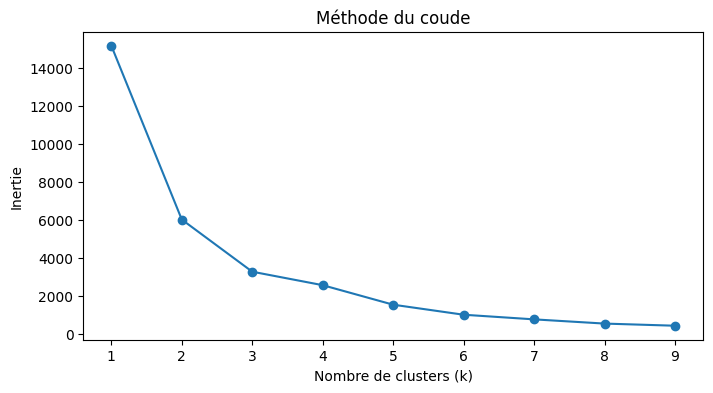

In [42]:
inertie = []
k_values = range(1, 10)  # On teste k de 1 à 9

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertie.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertie, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()


In [43]:
# Choix du nombre de clusters (changez ce nombre selon votre observation du graphique)
k = 3

# Créer l'instance du modèle K-means
kmeans = KMeans(n_clusters=k, random_state=42)

# Ajuster le modèle aux données normalisées
kmeans.fit(X_scaled)

# Affecter les labels obtenus à chaque acteur
df['cluster'] = kmeans.labels_

# Afficher quelques lignes avec le numéro de cluster assigné
print(df[['bankable acteur', 'moyenne', 'cluster']].head())


   bankable acteur    moyenne  cluster
0    Harrison Ford  1549858.0        0
1      Adam Driver  1402233.0        0
2    Ewan McGregor   841258.0        1
3  Natalie Portman  1348049.0        0
4   Jamel Debbouze  2206938.0        2


In [44]:
# Les centres des clusters (en échelle normalisée)
centers_scaled = kmeans.cluster_centers_

# Pour remettre ces centres à l'échelle d'origine :
centers = scaler.inverse_transform(centers_scaled)
print("Centres de clusters (revenus en original) :")
print(centers)


Centres de clusters (revenus en original) :
[[1108253.9120983 ]
 [ 579630.80507254]
 [1996506.13139535]]


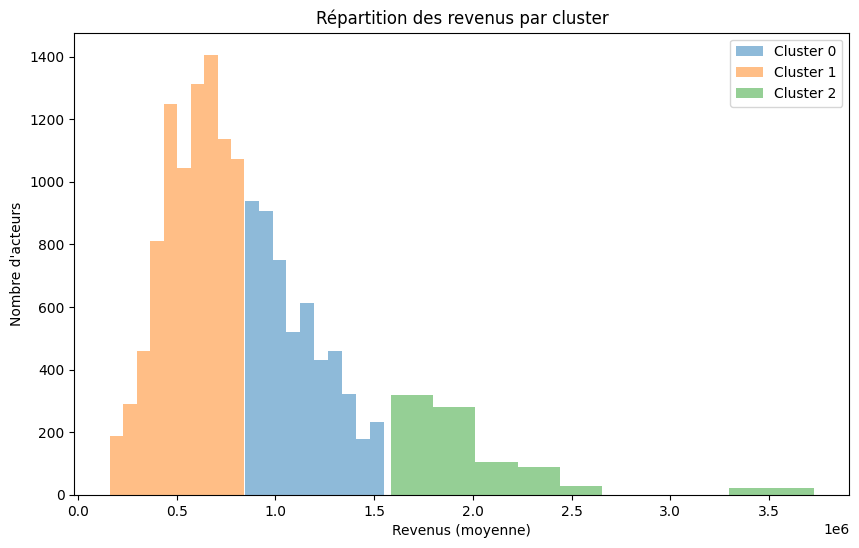

In [45]:
# Visualisation simple : distribution des revenus selon le cluster
plt.figure(figsize=(10,6))
for cluster in range(k):
    cluster_data = df[df['cluster'] == cluster]['moyenne']
    plt.hist(cluster_data, alpha=0.5, bins=10, label=f'Cluster {cluster}')
    
plt.xlabel("Revenus (moyenne)")
plt.ylabel("Nombre d'acteurs")
plt.title("Répartition des revenus par cluster")
plt.legend()
plt.show()


In [46]:
df.to_csv("bankable_acteur_clustered.csv", index=False)
print("Le fichier 'bankable_acteur_clustered.csv' a été créé avec succès.")


Le fichier 'bankable_acteur_clustered.csv' a été créé avec succès.


In [48]:
import pandas as pd

# Charger le fichier CSV contenant toutes les informations
df = pd.read_csv("films_backup.csv")

# Extraire les colonnes 'realisateur' et 'moyenne_fr_realisateur'
directors_df = df[["realisateur", "moyenne_fr_realisateur"]].copy()

# Optionnel : Si un même réalisateur apparaît plusieurs fois et que vous souhaitez avoir une ligne unique par réalisateur,
# vous pouvez grouper par 'realisateur' (ici en prenant la moyenne des valeurs numériques)
directors_df = directors_df.groupby("realisateur", as_index=False).mean()

# S'assurer de supprimer éventuellement les lignes vides ou manquantes
directors_df = directors_df.dropna(subset=["realisateur", "moyenne_fr_realisateur"])

print("Extrait des réalisateurs :")
print(directors_df.head())


Extrait des réalisateurs :
            realisateur  moyenne_fr_realisateur
0   - Dardenne (frères)                301977.0
1             - Maïwenn                899657.0
2    - Russo (brothers)               2851359.0
3  . Nakache & Toledano               3903528.0
4           Adrian Lyne               1212432.0


In [49]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Extraire la variable sur laquelle on va appliquer K-means en forme de tableau 2D
X = directors_df[["moyenne_fr_realisateur"]].values

# Normaliser les données : la transformation centrera les données à une moyenne nulle et une variance égale à 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Afficher les premières lignes normalisées pour vérifier
print("Données normalisées (moyenne_fr_realisateur) :")
print(X_scaled[:5])


Données normalisées (moyenne_fr_realisateur) :
[[-0.86576874]
 [-0.23285275]
 [ 1.83391105]
 [ 2.94811025]
 [ 0.09836177]]


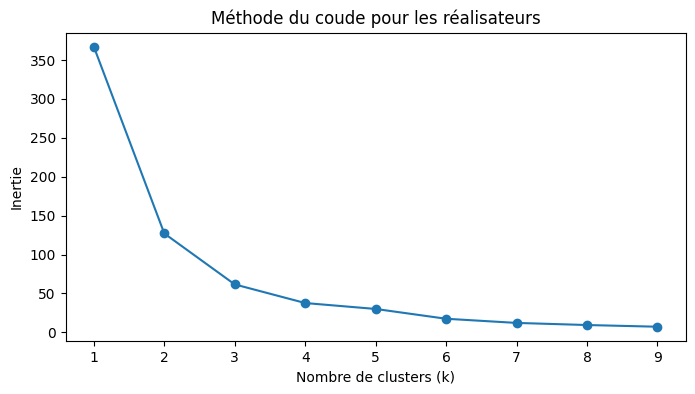

Répartitions des réalisateurs par cluster :
            realisateur  moyenne_fr_realisateur  cluster
0   - Dardenne (frères)                301977.0        1
1             - Maïwenn                899657.0        1
2    - Russo (brothers)               2851359.0        0
3  . Nakache & Toledano               3903528.0        0
4           Adrian Lyne               1212432.0        1


In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Optionnel : Utiliser la méthode du coude pour visualiser l'inertie en fonction de k
inertie = []
k_values = range(1, 10)  # Tester par exemple de 1 à 9 clusters
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertie.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertie, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude pour les réalisateurs")
plt.show()

# Supposons que l'analyse de la courbe du coude suggère k=3
k = 3

# Appliquer K-means avec le k choisi
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# Ajout des labels (clusters) au DataFrame des réalisateurs
directors_df["cluster"] = labels

print("Répartitions des réalisateurs par cluster :")
print(directors_df.head())


In [51]:
# Trier le DataFrame par numéro de cluster (facultatif, pour une meilleure lisibilité)
directors_df = directors_df.sort_values("cluster")

# Sauvegarder le DataFrame dans un fichier CSV
directors_df.to_csv("realisateur.csv", index=False)

print("Le fichier 'realisateur.csv' a été créé avec succès.")


Le fichier 'realisateur.csv' a été créé avec succès.


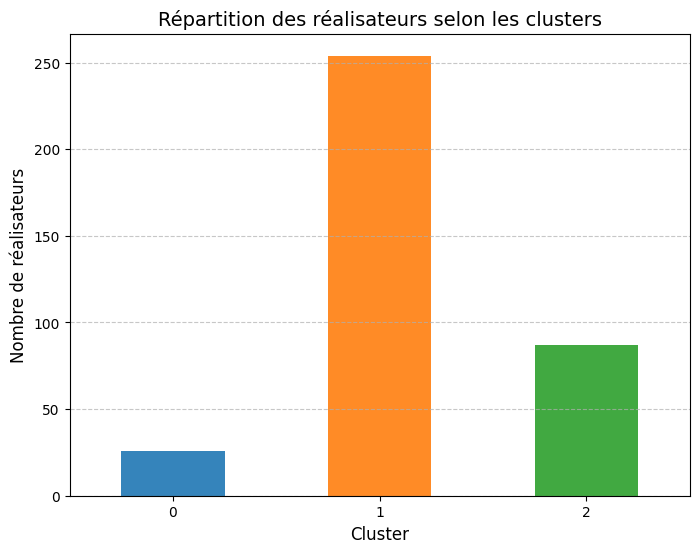

In [52]:
import matplotlib.pyplot as plt

# Répartition des réalisateurs par cluster
cluster_counts = directors_df["cluster"].value_counts()

# Création d'un graphique en barres
plt.figure(figsize=(8, 6))
cluster_counts.sort_index().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.9)

# Personnalisation du graphique
plt.title("Répartition des réalisateurs selon les clusters", fontsize=14)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Nombre de réalisateurs", fontsize=12)
plt.xticks(rotation=0)  # Pas de rotation pour les étiquettes
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Afficher le graphique
plt.show()


In [1]:
import pandas as pd

# Charger les deux fichiers CSV
realisateurs_df = pd.read_csv("realisateur.csv")  # Contient la colonne 'cluster_realisateur'
final_df = pd.read_csv("final_updatedmaxellie.csv")  # Fichier principal

# Effectuer la jointure sur la colonne 'realisateur'
# Nous utilisons un left join pour ne pas perdre les données présentes dans final_df
merged_df = pd.merge(final_df, realisateurs_df[["realisateur", "cluster"]], on="realisateur", how="left")

# Renommer la colonne 'cluster' pour clarifier qu'elle provient des réalisateurs
merged_df = merged_df.rename(columns={"cluster": "cluster_realisateur"})

# Sauvegarder le fichier enrichi dans un nouveau CSV
merged_df.to_csv("final_avecclusterreal.csv", index=False)

print("Le fichier 'final_enriched.csv' a été créé avec succès, avec la colonne 'cluster_realisateur' ajoutée.")


Le fichier 'final_enriched.csv' a été créé avec succès, avec la colonne 'cluster_realisateur' ajoutée.


In [10]:

import pandas as pd
import numpy as np

# 1. Charger les fichiers CSV
final_df = pd.read_csv("final_avecclusterreal.csv")
actors_df = pd.read_csv("bankable_acteur_clustered.csv")

# 2. Nettoyer les colonnes utilisées pour la jonction : 
#    On s'assure que les noms sont bien des chaînes et on retire les espaces superflus.
final_df["acteurs principal"] = final_df["acteurs principal"].astype(str).str.strip()
final_df["acteurs secondaires"] = final_df["acteurs secondaires"].astype(str).str.strip()
actors_df["bankable acteur"] = actors_df["bankable acteur"].astype(str).str.strip()

# 3. Création d'un dictionnaire de correspondance (mapping)
#    On suppose que le fichier actors_df contient une colonne "bankable acteurs" et "cluster_acteur"
actor_cluster_map = dict(zip(actors_df["bankable acteur"], actors_df["cluster"]))

# 4. Fonction pour obtenir les clusters à partir d'une chaîne contenant potentiellement plusieurs noms
def get_clusters(actor_str, mapping):
    """
    Si l'entrée est vide ou "nan", renvoie np.nan.
    Sinon, découpe la chaîne sur la virgule, nettoie chaque nom,
    et récupère le cluster correspondant dans le dictionnaire mapping.
    Retourne une chaîne avec les clusters recherchés (sans doublons) séparés par des virgules.
    """
    # Vérifier si la valeur est nan ou vide
    if pd.isna(actor_str) or actor_str.lower().strip() == "nan" or actor_str.strip() == "":
        return np.nan
    # Découper la chaîne sur la virgule et supprimer les espaces superflus
    names = [name.strip() for name in actor_str.split(",") if name.strip() != ""]
    clusters = []
    for name in names:
        if name in mapping:
            clusters.append(mapping[name])
    if len(clusters) == 0:
        return np.nan
    # Supprimer les doublons s'il y en a puis joindre avec une virgule (si plusieurs clusters)
    unique_clusters = list(set(clusters))
    return ", ".join(map(str, unique_clusters))

# 5. Appliquer la fonction pour chaque ligne et créer les deux nouvelles colonnes.
final_df["cluster_acteur_principal"] = final_df["acteurs principal"].apply(lambda x: get_clusters(x, actor_cluster_map))
final_df["cluster_acteur_secondaire"] = final_df["acteurs secondaires"].apply(lambda x: get_clusters(x, actor_cluster_map))

# 6. Sauvegarder le DataFrame enrichi dans un nouveau fichier CSV
final_df.to_csv("final_enriched_with_cluster_acteur_separated.csv", index=False)
print("Le fichier 'final_enriched_with_cluster_acteur_separated.csv' a été créé avec succès.")



Le fichier 'final_enriched_with_cluster_acteur_separated.csv' a été créé avec succès.


In [7]:
print(actors_df.head())


   bankable acteur    moyenne  cluster
0    Harrison Ford  1549858.0        0
1      Adam Driver  1402233.0        0
2    Ewan McGregor   841258.0        1
3  Natalie Portman  1348049.0        0
4   Jamel Debbouze  2206938.0        2


In [9]:
print("Colonnes disponibles dans actors_df :")
print(actors_df.columns)


Colonnes disponibles dans actors_df :
Index(['bankable acteur', 'moyenne', 'cluster'], dtype='object')


In [2]:
import pandas as pd
import re

# Charger le fichier CSV
file_path = "allocine_cleaned_202504151041.csv"
df = pd.read_csv(file_path)

# Fonction pour supprimer les caractères Unicode invisibles
def remove_invisible_chars(value):
    if isinstance(value, str):  # Vérifier que la valeur est une chaîne de caractères
        # Supprimer les caractères invisibles comme les espaces insécables ou les caractères de contrôle
        return re.sub(r'[\u200b-\u200f\u202a-\u202e\u2060-\u206f]', '', value)
    return value

# Appliquer ce nettoyage à toutes les colonnes du DataFrame
df_cleaned = df.applymap(remove_invisible_chars)

# Sauvegarder le fichier nettoyé
cleaned_file_path = "allocine_cleaned_cleaned.csv"
df_cleaned.to_csv(cleaned_file_path, index=False)

print(f"Fichier nettoyé enregistré sous {cleaned_file_path}.")


/tmp/ipykernel_28802/1231920446.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df.applymap(remove_invisible_chars)


Fichier nettoyé enregistré sous allocine_cleaned_cleaned.csv.


In [3]:
import pandas as pd

# Charger les deux fichiers CSV
allocine_df = pd.read_csv("allocine_cleaned_cleaned.csv")
final_clustered_df = pd.read_csv("final_clustered.csv")

# Vérifier rapidement les colonnes pour s'assurer que les clés existent bien
print("Colonnes dans allocine_df :", allocine_df.columns.tolist())
print("Colonnes dans final_clustered_df :", final_clustered_df.columns.tolist())

# Fusionner les DataFrames
# On réalise une jointure left sur le DataFrame allocine_df (qui contient plus de colonnes)
merged_df = pd.merge(allocine_df, 
                     final_clustered_df, 
                     left_on="title", 
                     right_on="titre", 
                     how="left")

# Sauvegarder le résultat dans un nouveau fichier CSV
merged_df.to_csv("merged_dataset.csv", index=False)

print("Le fichier 'merged_dataset.csv' a été créé avec succès.")


Colonnes dans allocine_df : ['id', 'title', 'original_title', 'release_date', 'duration', 'genres', 'press_rating', 'audience_rating', 'director', 'writer', 'audience', 'distributor', 'movie_type', 'nationality', 'languages', 'synopsis', 'actors', 'box_office_fr', 'box_office_us', 'image_url']
Colonnes dans final_clustered_df : ['film_id', 'realisateur_id', 'rang', 'titre', 'titre_vo', 'realisateur', 'genre', 'annee', 'pays', 'entrees', 'salles', 'moy_salle', 'part_marche', 'affiche', 'moyenne_fr_realisateur', 'sortie', 'distributeur', 'classification', 'acteurs', 'moyennes_individuelles_acteurs', 'acteurs principal', 'acteurs secondaires', 'max_moyenne', 'moyennebestactors', 'Pays', 'cluster_realisateur', 'cluster_acteur_principal', 'cluster_acteur_secondaire']
Le fichier 'merged_dataset.csv' a été créé avec succès.


In [4]:
import pandas as pd

# Charger le fichier complet (remplacez 'votre_database.csv' par le nom réel du fichier)
df = pd.read_csv("merged_dataset.csv")

# Convertir la colonne "release_date" en datetime (en gérant les erreurs le cas échéant)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Filtrer pour ne conserver que les films dont la date de sortie est à partir du 1er janvier 2000 inclus
df_filtre = df[df['release_date'] >= pd.Timestamp("2000-01-01")]

# Sauvegarder le nouveau fichier CSV en conservant toutes les colonnes
df_filtre.to_csv("films_depuis_2000.csv", index=False)

print("Les films sortis à partir de 2000 inclus ont été sauvegardés dans 'films_depuis_2000.csv'")


Les films sortis à partir de 2000 inclus ont été sauvegardés dans 'films_depuis_2000.csv'


In [5]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
df = pd.read_csv("allocinejpbox.csv")

# Visualiser les premières lignes du fichier pour vérifier son contenu
print("Aperçu des données :")
print(df.head())

# Afficher les colonnes présentes dans le fichier
print("Colonnes disponibles dans le fichier :")
print(df.columns)

# Afficher la forme des données (nombre de lignes et de colonnes)
print("Forme des données :")
print(df.shape)


Aperçu des données :
   id              title          original_title release_date  duration  \
0   1  Monsieur Constant                     NaN   2025-05-28     108.0   
1   2             Reagan                     NaN   2025-04-30     135.0   
2   3           Ne Zha 2  Nezha: Mo Tong Nao Hai   2025-04-23     144.0   
3   4  Notes Laura Fiori                     NaN   2025-04-15      75.0   
4   5       Trois contes                     NaN   2025-04-14       NaN   

                      genres  press_rating  audience_rating  \
0     {"Comédie dramatique"}           NaN              NaN   
1  {Biopic,Drame,Historique}           NaN              NaN   
2    {Animation,Fantastique}           NaN              NaN   
3                    {Drame}           NaN              NaN   
4                {Animation}           NaN              NaN   

            director                              writer  ... acteurs  \
0     {"Alan Simon"}                      {"Alan Simon"}  ...     NaN   
1  

In [6]:
import pandas as pd
import numpy as np
import re

# 1. Charger le fichier CSV
df = pd.read_csv("allocinejpbox.csv")

# 2. Supprimer les espaces superflus dans toutes les colonnes de type chaîne
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# 3. Conversion et gestion des types

# Convertir les dates - on s'assure que "release_date" est au format datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Convertir certaines colonnes numériques en float/int
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
df['press_rating'] = pd.to_numeric(df['press_rating'], errors='coerce')
df['audience_rating'] = pd.to_numeric(df['audience_rating'], errors='coerce')
df['box_office_fr'] = pd.to_numeric(df['box_office_fr'], errors='coerce')
df['box_office_us'] = pd.to_numeric(df['box_office_us'], errors='coerce')

# 4. Fonction pour nettoyer les chaînes de caractères "JSON-like"
def clean_bracketed_string(s):
    if pd.isnull(s):
        return s
    # Supprime les accolades et les guillemets redondants
    s = s.replace("{", "").replace("}", "")
    s = s.replace('""', '"')
    # Optionnel : supprimer les guillemets isolés
    s = re.sub(r'^"|"$', '', s)
    return s.strip()

# Appliquer le nettoyage à quelques colonnes présentant ce type de format
colonnes_json = ['genres', 'director', 'writer', 'nationality', 'languages']
for col in colonnes_json:
    if col in df.columns:
        df[col] = df[col].apply(clean_bracketed_string)

# Vous pouvez appliquer ce nettoyage à d'autres colonnes si nécessaire (ex. "actors", "acteurs principal", etc.)

# 5. Gestion des valeurs manquantes

# Exemple : imputer la moyenne pour les notes de presse et d'audience
df['press_rating'].fillna(df['press_rating'].mean(), inplace=True)
df['audience_rating'].fillna(df['audience_rating'].mean(), inplace=True)

# Autres imputations : par exemple pour la durée, on peut utiliser la moyenne
df['duration'].fillna(df['duration'].mean(), inplace=True)

# Pour les revenus (box_office_fr, box_office_us), si ce n'est pas obligatoire, on peut les remplacer par 0 sinon utiliser une autre méthode d'imputation
df['box_office_fr'].fillna(0, inplace=True)
df['box_office_us'].fillna(0, inplace=True)

# Si la date de sortie est essentielle pour votre modèle, on peut supprimer les lignes sans date valide
df = df.dropna(subset=['release_date'])

# 6. (Optionnel) Filtrage supplémentaire
# Par exemple, si vous ne souhaitez conserver que les films à partir d'une certaine année,
# vous pouvez filtrer avec :
# df = df[df['release_date'] >= pd.Timestamp("2000-01-01")]

# 7. Visualiser un aperçu des données nettoyées
print("Aperçu du DataFrame nettoyé :")
print(df.head())
print("\nInformations sur les types de données :")
print(df.dtypes)

# 8. Sauvegarder la base nettoyée
df.to_csv("allocinejpbox_cleaned.csv", index=False)
print("La base nettoyée a été sauvegardée dans 'allocinejpbox_cleaned.csv'.")


/tmp/ipykernel_28802/115578655.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipykernel_28802/115578655.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['press_rating'].fillna(df['press_rating'].mean(), inplace=True)
/tmp/ipykernel_28802/115578655.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change 

Aperçu du DataFrame nettoyé :
   id              title          original_title release_date    duration  \
0   1  Monsieur Constant                     NaN   2025-05-28  108.000000   
1   2             Reagan                     NaN   2025-04-30  135.000000   
2   3           Ne Zha 2  Nezha: Mo Tong Nao Hai   2025-04-23  144.000000   
3   4  Notes Laura Fiori                     NaN   2025-04-15   75.000000   
4   5       Trois contes                     NaN   2025-04-14  102.950049   

                    genres  press_rating  audience_rating       director  \
0       Comédie dramatique      3.067464         3.008576     Alan Simon   
1  Biopic,Drame,Historique      3.067464         3.008576  Sean McNamara   
2    Animation,Fantastique      3.067464         3.008576        Yu Yang   
3                    Drame      3.067464         3.008576                  
4                Animation      3.067464         3.008576                  

                           writer  ... acteurs moy

In [9]:
import pandas as pd

# Charger les fichiers CSV
allocine_df = pd.read_csv("allocinejpbox_cleaned.csv")
leo_df = pd.read_csv("leo.csv")

# Fusionner les DataFrames sur les colonnes "title" (allocine) et "titre" (leo)
merged_df = pd.merge(allocine_df, 
                     leo_df[["titre", "budget"]], 
                     left_on="title", 
                     right_on="titre", 
                     how="left")

# Vérifier la colonne "titre" avant suppression
if 'titre' in merged_df.columns:
    merged_df = merged_df.drop(columns=["titre"])

# Sauvegarder le fichier fusionné
merged_df.to_csv("allocinejpbox_with_budget.csv", index=False)

print("Le fichier 'allocinejpbox_with_budget.csv' a été créé avec succès avec la colonne 'budget' ajoutée.")


Le fichier 'allocinejpbox_with_budget.csv' a été créé avec succès avec la colonne 'budget' ajoutée.


In [8]:
print("Colonnes disponibles dans leo_df :")
print(leo_df.columns)


Colonnes disponibles dans leo_df :
Index(['film_id', 'titre', 'genre_principale', 'genres', 'date_sortie_france',
       'date_sortie_usa', 'duree_minutes', 'synopsis', 'realisateur',
       'acteurs', 'pays_origine', 'budget', 'box_office_demarrage',
       'box_office_france', 'recette_usa', 'recette_monde', 'image_url',
       'note_moyenne'],
      dtype='object')


In [10]:
import pandas as pd

# Charger le fichier nettoyé
df = pd.read_csv("allocinejpbox_with_budget.csv")

# Calculer le nombre de lignes vides dans la colonne "budget"
missing_budget = df['budget'].isna().sum()

print(f"Nombre de lignes vides dans la colonne 'budget' : {missing_budget}")


Nombre de lignes vides dans la colonne 'budget' : 6835


In [11]:
import pandas as pd
import re

# Charger le fichier CSV
df = pd.read_csv("allocinejpbox_with_budget.csv")

# Fonction pour nettoyer les chaînes dans la colonne 'actors'
def clean_actors(actors_str):
    if pd.isnull(actors_str):  # Vérifie les valeurs nulles
        return actors_str
    # Supprimer les accolades et les guillemets redondants
    cleaned_str = actors_str.replace("{", "").replace("}", "").replace('"', "")
    # Supprimer les espaces superflus et retourner la liste sous forme de chaîne, séparée par des virgules
    cleaned_str = ", ".join([actor.strip() for actor in cleaned_str.split(",")])
    return cleaned_str

# Appliquer la fonction sur la colonne 'actors'
df['actors'] = df['actors'].apply(clean_actors)

# Visualiser un aperçu des données nettoyées
print("Aperçu des données nettoyées :")
print(df['actors'].head())

# Sauvegarder le fichier nettoyé
df.to_csv("allocinejpboxbudget.csv", index=False)
print("Le fichier nettoyé a été sauvegardé sous 'allocinejpbox_cleaned.csv'.")


Aperçu des données nettoyées :
0            Jean-Claude Drouot, Cali, Danièle Evenou
1     Dennis Quaid, Penelope Ann Miller, David Henrie
2                   Joseph Cao, Mo Han, Hao Chen (II)
3    Ilaria Benigna, Raphaël Mathon, Mathilde Mosnier
4                                                 NaN
Name: actors, dtype: object
Le fichier nettoyé a été sauvegardé sous 'allocinejpbox_cleaned.csv'.


In [12]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv("allocinejpboxbudget.csv")

# Fonction pour nettoyer les guillemets dans les chaînes de la colonne 'writer'
def clean_writer(writer_str):
    if pd.isnull(writer_str):  # Vérifie si la valeur est NaN
        return writer_str
    # Supprimer les guillemets redondants et les espaces inutiles
    cleaned_str = writer_str.replace('"', '').strip()
    return cleaned_str

# Appliquer la fonction à la colonne 'writer'
df['writer'] = df['writer'].apply(clean_writer)

# Visualiser les premières lignes de la colonne nettoyée
print("Aperçu des données nettoyées dans la colonne 'writer' :")
print(df['writer'].head())

# Sauvegarder le fichier nettoyé
df.to_csv("allocinejpboxv1.csv", index=False)

print("Le fichier nettoyé a été sauvegardé sous 'allocinejpbox_cleaned_with_writer.csv'.")


Aperçu des données nettoyées dans la colonne 'writer' :
0                      Alan Simon
1    Jonas McCord,Howard Klausner
2                         Yu Yang
3                             NaN
4                             NaN
Name: writer, dtype: object
Le fichier nettoyé a été sauvegardé sous 'allocinejpbox_cleaned_with_writer.csv'.


In [13]:
import pandas as pd
import re

# Charger le fichier CSV contenant les réalisateurs
df = pd.read_csv("realisateur.csv")

# Fonction pour nettoyer les noms des réalisateurs
def clean_names(name):
    if pd.isnull(name):  # Vérifie si la valeur est NaN
        return name
    # Supprimer les caractères indésirables en début de chaîne (ex: '-', '.', espaces multiples)
    cleaned_name = re.sub(r"^[\-\.\s]+", "", name)
    return cleaned_name

# Appliquer le nettoyage sur la colonne 'realisateur' (ou la colonne qui contient les noms)
if 'realisateur' in df.columns:
    df['realisateur'] = df['realisateur'].apply(clean_names)
else:
    print("La colonne 'realisateur' est introuvable dans le fichier CSV.")

# Visualiser un aperçu des données nettoyées
print("Aperçu des noms nettoyés :")
print(df['realisateur'].head())

# Sauvegarder le fichier nettoyé
df.to_csv("realisateur_cleaned.csv", index=False)
print("Le fichier nettoyé a été sauvegardé sous 'realisateur_cleaned.csv'.")


Aperçu des noms nettoyés :
0          Andrew Adamson
1          Andrew Stanton
2            Ron Clements
3    Phlippe de Chauveron
4             Lee Unkrich
Name: realisateur, dtype: object
Le fichier nettoyé a été sauvegardé sous 'realisateur_cleaned.csv'.


In [15]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv("allocinejpboxv1.csv")

# Fonction pour nettoyer la colonne 'budget'
def clean_budget(budget_str):
    if pd.isnull(budget_str):  # Vérifie les valeurs nulles (NaN)
        return budget_str
    # Supprimer les symboles non numériques et convertir en valeur numérique
    cleaned_budget = ''.join(c for c in budget_str if c.isdigit())
    return pd.to_numeric(cleaned_budget, errors='coerce')  # Convertir en numérique

# Appliquer la fonction à la colonne 'budget'
df['budget'] = df['budget'].astype(str).apply(clean_budget)

# Visualiser un aperçu des données nettoyées
print("Aperçu des budgets nettoyés :")
print(df['budget'].head())

# Sauvegarder le fichier nettoyé
df.to_csv("allocinejpboxv1_cleaned.csv", index=False)
print("Le fichier nettoyé a été sauvegardé sous 'allocinejpboxv1_cleaned.csv'.")


Aperçu des budgets nettoyés :
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: budget, dtype: float64
Le fichier nettoyé a été sauvegardé sous 'allocinejpboxv1_cleaned.csv'.


In [16]:
import pandas as pd
import numpy as np

# 1. Charger les deux fichiers CSV
allocine_df = pd.read_csv("allocinejpboxv2.csv")
actors_df = pd.read_csv("actors.csv")

# 2. Créer des dictionnaires de correspondance
# On s'assure que les noms d'acteurs sont nettoyés (par exemple en supprimant les espaces superflus)
actors_df["bankable acteur"] = actors_df["bankable acteur"].astype(str).str.strip()
actor_moyenne_map = dict(zip(actors_df["bankable acteur"], actors_df["moyenne"]))
actor_cluster_map = dict(zip(actors_df["bankable acteur"], actors_df["cluster_acteur"]))

# 3. Fonction pour mettre à jour les colonnes cibles pour chaque ligne de allocine_df
def update_actor_values(row):
    # Si la colonne moyennes_individuelles_acteurs est vide, chercher une correspondance
    if pd.isnull(row.get("moyennes_individuelles_acteurs")) or str(row.get("moyennes_individuelles_acteurs")).strip() == "":
        # Vérifier que la colonne "actors" n'est pas vide
        if pd.notnull(row.get("actors")):
            # Séparer les noms supposés séparés par des virgules, et nettoyer les espaces
            actors_list = [actor.strip() for actor in str(row["actors"]).split(",")]
            # Parcourir la liste et dès qu'on trouve une correspondance dans notre dictionnaire, on l'assigne
            for actor in actors_list:
                if actor in actor_moyenne_map:
                    row["moyennes_individuelles_acteurs"] = actor_moyenne_map[actor]
                    break
    # Si la colonne cluster_acteur_principal est vide, chercher une correspondance
    if pd.isnull(row.get("cluster_acteur_principal")) or str(row.get("cluster_acteur_principal")).strip() == "":
        if pd.notnull(row.get("actors")):
            actors_list = [actor.strip() for actor in str(row["actors"]).split(",")]
            for actor in actors_list:
                if actor in actor_cluster_map:
                    row["cluster_acteur_principal"] = actor_cluster_map[actor]
                    break
    return row

# 4. Appliquer la fonction sur l'ensemble du DataFrame
allocine_df = allocine_df.apply(update_actor_values, axis=1)

# 5. Sauvegarder le fichier mis à jour
allocine_df.to_csv("allocinejpboxv3.csv", index=False)
print("Le fichier 'allocinejpboxv2_updated.csv' a été créé avec succès.")


Le fichier 'allocinejpboxv2_updated.csv' a été créé avec succès.


In [17]:
import pandas as pd

# Charger les deux versions des fichiers
df_v2 = pd.read_csv("allocinejpboxv2.csv")
df_updated = pd.read_csv("allocinejpboxv3.csv")

# Définition d'une fonction pour déterminer si une cellule est considérée comme vide :
def is_empty(x):
    return pd.isna(x) or str(x).strip() == ''

# Comparaison pour la colonne 'moyennes_individuelles_acteurs'
mask_moyenne = df_v2['moyennes_individuelles_acteurs'].apply(is_empty) & df_updated['moyennes_individuelles_acteurs'].apply(lambda x: not is_empty(x))
count_moyenne = mask_moyenne.sum()

# Comparaison pour la colonne 'cluster_acteur_principal'
mask_cluster = df_v2['cluster_acteur_principal'].apply(is_empty) & df_updated['cluster_acteur_principal'].apply(lambda x: not is_empty(x))
count_cluster = mask_cluster.sum()

# Pour avoir le nombre total de films (lignes) ayant au moins une modification
mask_any = mask_moyenne | mask_cluster
count_any = mask_any.sum()

print("Nombre de films où 'moyennes_individuelles_acteurs' a été modifiée :", count_moyenne)
print("Nombre de films où 'cluster_acteur_principal' a été modifiée :", count_cluster)
print("Nombre total de films ayant au moins une modification :", count_any)


Nombre de films où 'moyennes_individuelles_acteurs' a été modifiée : 1223
Nombre de films où 'cluster_acteur_principal' a été modifiée : 1466
Nombre total de films ayant au moins une modification : 1466


In [18]:
import pandas as pd
import numpy as np

# 1. Charger les deux fichiers CSV
allocine_df = pd.read_csv("allocinejpboxv3.csv")
realisateur_df = pd.read_csv("realisateurV2.csv")

# 2. Normaliser les noms en enlevant les espaces superflus et en passant en minuscules pour faciliter la correspondance
allocine_df['director'] = allocine_df['director'].astype(str).str.strip().str.lower()
realisateur_df['realisateur'] = realisateur_df['realisateur'].astype(str).str.strip().str.lower()

# 3. Créer des dictionnaires d'association
#    Un dictionnaire pour associer le nom du réalisateur à sa moyenne_fr_realisateur
#    Un autre dictionnaire pour associer le nom du réalisateur à son cluster_realisateur
moyenne_map = dict(zip(realisateur_df['realisateur'], realisateur_df['moyenne_fr_realisateur']))
cluster_map = dict(zip(realisateur_df['realisateur'], realisateur_df['cluster_realisateur']))

# 4. Fonction pour mettre à jour chaque ligne
def update_director_info(row):
    director = row.get("director", "")
    if director:
        # Mise à jour de la colonne moyenne_fr_realisateur si elle est vide (NaN ou chaîne vide)
        if (pd.isna(row.get("moyenne_fr_realisateur")) or str(row.get("moyenne_fr_realisateur")).strip() == "") and director in moyenne_map:
            row["moyenne_fr_realisateur"] = moyenne_map[director]
        # Mise à jour de la colonne cluster_realisateur si elle est vide
        if (pd.isna(row.get("cluster_realisateur")) or str(row.get("cluster_realisateur")).strip() == "") and director in cluster_map:
            row["cluster_realisateur"] = cluster_map[director]
    return row

# 5. Appliquer la fonction de mise à jour sur chaque ligne du DataFrame
allocine_df = allocine_df.apply(update_director_info, axis=1)

# 6. Sauvegarder le DataFrame mis à jour dans un nouveau fichier CSV
allocine_df.to_csv("allocinejpboxv3_updated.csv", index=False)
print("Le fichier 'allocinejpboxv3_updated.csv' a été créé avec succès.")


Le fichier 'allocinejpboxv3_updated.csv' a été créé avec succès.


In [19]:
import pandas as pd

# Charger les deux fichiers CSV
df_original = pd.read_csv("allocinejpboxv3.csv")
df_updated = pd.read_csv("allocinejpboxv3_updated.csv")

# Fonction pour identifier si une ligne a été modifiée
def count_modified_rows(column):
    # Vérifier les lignes où la colonne est vide dans l'original mais remplie dans la version mise à jour
    mask = df_original[column].isna() & ~df_updated[column].isna()
    return mask.sum()

# Vérifier le nombre de lignes modifiées pour chaque colonne
modified_moyenne = count_modified_rows("moyenne_fr_realisateur")
modified_cluster = count_modified_rows("cluster_realisateur")

# Total des lignes modifiées (au moins une des deux colonnes a changé)
total_modified = ((df_original["moyenne_fr_realisateur"].isna() & ~df_updated["moyenne_fr_realisateur"].isna()) |
                  (df_original["cluster_realisateur"].isna() & ~df_updated["cluster_realisateur"].isna())).sum()

# Afficher les résultats
print(f"Nombre de lignes modifiées dans 'moyenne_fr_realisateur' : {modified_moyenne}")
print(f"Nombre de lignes modifiées dans 'cluster_realisateur' : {modified_cluster}")
print(f"Nombre total de lignes modifiées : {total_modified}")


Nombre de lignes modifiées dans 'moyenne_fr_realisateur' : 443
Nombre de lignes modifiées dans 'cluster_realisateur' : 443
Nombre total de lignes modifiées : 443
